In [1]:
# Cell 1 — Setup and Load Data
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.utils import class_weight
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset.csv')

# Create real target variable
df['target'] = (df['event_type'] == 'purchase').astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Purchase rate: {df['target'].mean():.2%}")
print("Data loaded successfully!")

Mounted at /content/drive
Dataset shape: (36673, 36)
Purchase rate: 7.18%
Data loaded successfully!


In [2]:
# Cell 2 — Prepare Features
categorical_cols = [
    'Customer_ID', 'Product_ID', 'Category', 'Subcategory',
    'event_type', 'Gender', 'Location',
    'Customer_Segment', 'price_segment', 'engagement_level',
    'Season_x'
]

numerical_cols = [
    'Age', 'Price', 'income', 'Interaction_Value',
    'Time_Spent_Seconds', 'hour', 'day_of_week', 'month',
    'Product_Rating', 'browse_count', 'purchase_count',
    'interaction_score', 'already_purchased'
]

# Encode categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Scale numerical columns
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Prepare X and y
feature_cols = categorical_cols + numerical_cols
X = df[feature_cols].values
y = df['target'].values

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Calculate class weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: weights[0], 1: weights[1]}

print(f"Training samples  : {X_train.shape[0]}")
print(f"Testing samples   : {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Class weights     : {class_weights}")
print("Features ready!")

Training samples  : 29338
Testing samples   : 7335
Number of features: 24
Class weights     : {0: np.float64(0.5386677438307873), 1: np.float64(6.965337132003799)}
Features ready!


In [3]:
# Cell 3 — Baseline Model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

def build_baseline(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(inputs)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

early_stop = EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

baseline = build_baseline(X_train.shape[1])

print("Training Baseline Model...")
baseline_history = baseline.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)
print("\nBaseline training complete!")

Training Baseline Model...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5070 - auc: 0.5150 - loss: 48.2420 - precision: 0.0758 - recall: 0.5180 - val_accuracy: 0.1102 - val_auc: 0.5089 - val_loss: 3.7705 - val_precision: 0.0717 - val_recall: 0.9544
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4866 - auc: 0.4885 - loss: 8.2962 - precision: 0.0688 - recall: 0.4983 - val_accuracy: 0.0727 - val_auc: 0.5167 - val_loss: 1.8020 - val_precision: 0.0717 - val_recall: 0.9981
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5032 - auc: 0.5094 - loss: 2.8991 - precision: 0.0739 - recall: 0.5182 - val_accuracy: 0.0725 - val_auc: 0.5135 - val_loss: 2.1409 - val_precision: 0.0717 - val_recall: 0.9981
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4822 - auc: 0.5045 - loss: 1.4579 - precision: 0.0750 - recall: 0.5319 - val_accuracy: 0.9283 - val_auc: 0.4869 - val_loss: 0.4262 - val_precision: 0.0000e+00 - val_recall: 0.0000

In [4]:
# Cell 4 — Fix Data Leakage and Retrain

# Remove event_type from features since it directly defines our target
categorical_cols_fixed = [
    'Customer_ID', 'Product_ID', 'Category', 'Subcategory',
    'Gender', 'Location', 'Customer_Segment',
    'price_segment', 'engagement_level', 'Season_x'
]

numerical_cols_fixed = [
    'Age', 'Price', 'income', 'Interaction_Value',
    'Time_Spent_Seconds', 'hour', 'day_of_week', 'month',
    'Product_Rating', 'browse_count', 'purchase_count',
    'already_purchased'
]

# Reload and re-encode fresh
df3 = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset.csv')
df3['target'] = (df3['event_type'] == 'purchase').astype(int)

# Encode
label_encoders2 = {}
for col in categorical_cols_fixed:
    le = LabelEncoder()
    df3[col] = le.fit_transform(df3[col].astype(str))
    label_encoders2[col] = le

# Scale
scaler2 = MinMaxScaler()
df3[numerical_cols_fixed] = scaler2.fit_transform(df3[numerical_cols_fixed])

# Prepare X and y
feature_cols_fixed = categorical_cols_fixed + numerical_cols_fixed
X2 = df3[feature_cols_fixed].values
y2 = df3['target'].values

# Split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Class weights
weights2 = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train2),
    y=y_train2
)
class_weights2 = {0: weights2[0], 1: weights2[1]}

print(f"Training samples  : {X_train2.shape[0]}")
print(f"Testing samples   : {X_test2.shape[0]}")
print(f"Features          : {X_train2.shape[1]}")
print(f"Class weights     : {class_weights2}")
print("\nData leakage fixed!")

Training samples  : 29338
Testing samples   : 7335
Features          : 22
Class weights     : {0: np.float64(0.5386677438307873), 1: np.float64(6.965337132003799)}

Data leakage fixed!


In [5]:
# Cell 5 — Train Baseline Model (No Leakage)
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

baseline2 = build_baseline(X_train2.shape[1])

print("Training Baseline Model...")
baseline_history2 = baseline2.fit(
    X_train2, y_train2,
    validation_data=(X_test2, y_test2),
    epochs=30,
    batch_size=256,
    class_weight=class_weights2,
    callbacks=[early_stop],
    verbose=1
)
print("\nBaseline training complete!")

Training Baseline Model...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5087 - auc: 0.5003 - loss: 90.0960 - precision: 0.0697 - recall: 0.4939 - val_accuracy: 0.7581 - val_auc: 0.4994 - val_loss: 1.1183 - val_precision: 0.0755 - val_recall: 0.2110
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5280 - auc: 0.5056 - loss: 10.3839 - precision: 0.0745 - recall: 0.4745 - val_accuracy: 0.7680 - val_auc: 0.4878 - val_loss: 0.5134 - val_precision: 0.0695 - val_recall: 0.1806
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5096 - auc: 0.4926 - loss: 4.3238 - precision: 0.0713 - recall: 0.4762 - val_accuracy: 0.8994 - val_auc: 0.4884 - val_loss: 0.4103 - val_precision: 0.0726 - val_recall: 0.0342
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4941 - auc: 0.4967 - loss: 2.4493 - precision: 0.0738 - recall: 0.5114 - val_accuracy: 0.8105 - val_auc: 0.4866 - val_loss: 0.4673 - val_precision: 0.0773 - val_recall: 0.1502
E

In [6]:
# Cell 6 — Better Target: Predict Interaction Score
df4 = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset.csv')

# Use interaction_score as target (1=view, 3=add_to_cart, 4=review, 5=purchase)
# Normalize it to 0-1
df4['target'] = (df4['interaction_score'] - 1) / 4

categorical_cols_v2 = [
    'Customer_ID', 'Product_ID', 'Category', 'Subcategory',
    'Gender', 'Location', 'Customer_Segment',
    'price_segment', 'engagement_level', 'Season_x'
]

numerical_cols_v2 = [
    'Age', 'Price', 'income', 'Interaction_Value',
    'Time_Spent_Seconds', 'hour', 'day_of_week', 'month',
    'Product_Rating', 'browse_count', 'purchase_count',
    'already_purchased'
]

# Encode
for col in categorical_cols_v2:
    le = LabelEncoder()
    df4[col] = le.fit_transform(df4[col].astype(str))

# Scale
scaler3 = MinMaxScaler()
df4[numerical_cols_v2] = scaler3.fit_transform(df4[numerical_cols_v2])

# Prepare X and y
X3 = df4[categorical_cols_v2 + numerical_cols_v2].values
y3 = df4['target'].values

# Split
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

print(f"Target distribution:")
print(pd.Series(df4['target']).value_counts().sort_index())
print(f"\nTraining samples: {X_train3.shape[0]}")
print(f"Testing samples : {X_test3.shape[0]}")
print(f"Features        : {X_train3.shape[1]}")

Target distribution:
target
0.00    26169
0.50     6549
0.75     1323
1.00     2632
Name: count, dtype: int64

Training samples: 29338
Testing samples : 7335
Features        : 22


In [7]:
# Cell 7 — Train Baseline on Interaction Score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

def build_baseline_v2(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(inputs)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

def build_deepfm_v2(input_dim):
    inputs = Input(shape=(input_dim,))
    # FM Part
    first_order = Dense(1, use_bias=True)(inputs)
    fm_dense = Dense(16, activation='relu')(inputs)
    fm_second = Dense(1)(fm_dense)
    # Deep Part
    deep = Dense(128, activation='relu')(inputs)
    deep = Dropout(0.2)(deep)
    deep = Dense(64, activation='relu')(deep)
    deep = Dropout(0.2)(deep)
    deep = Dense(32, activation='relu')(deep)
    # Combine
    combined = Concatenate()([first_order, fm_second, deep])
    combined = Dense(16, activation='relu')(combined)
    output = Dense(1, activation='sigmoid')(combined)
    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae', tf.keras.metrics.RootMeanSquaredError(name='rmse')]
    )
    return model

early_stop = EarlyStopping(
    monitor='val_mae',
    patience=5,
    restore_best_weights=True,
    mode='min'
)

# Train Baseline
baseline_v2 = build_baseline_v2(X_train3.shape[1])
print("Training Baseline Model...")
baseline_history_v2 = baseline_v2.fit(
    X_train3, y_train3,
    validation_data=(X_test3, y_test3),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
print("\nBaseline training complete!")

Training Baseline Model...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1991 - mae: 0.2510 - rmse: 0.4386 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1396 - mae: 0.1918 - rmse: 0.3736 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1367 - mae: 0.1881 - rmse: 0.3697 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1355 - mae: 0.1876 - rmse: 0.3681 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1396 - mae: 0.1915 - rmse: 0.3736 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1356 - mae: 0.1864 - rmse: 0.3681 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723

Baseline training complete!


In [8]:
# Cell 8 — Train DeepFM Model
early_stop2 = EarlyStopping(
    monitor='val_mae',
    patience=5,
    restore_best_weights=True,
    mode='min'
)

deepfm_v2 = build_deepfm_v2(X_train3.shape[1])
print("Training DeepFM Model...")
deepfm_history_v2 = deepfm_v2.fit(
    X_train3, y_train3,
    validation_data=(X_test3, y_test3),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop2],
    verbose=1
)
print("\nDeepFM training complete!")

Training DeepFM Model...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.2111 - mae: 0.2636 - rmse: 0.4521 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1377 - mae: 0.1894 - rmse: 0.3711 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1377 - mae: 0.1889 - rmse: 0.3710 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1354 - mae: 0.1868 - rmse: 0.3679 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1356 - mae: 0.1867 - rmse: 0.3683 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1369 - mae: 0.1890 - rmse: 0.3701 - val_loss: 0.1386 - val_mae: 0.1901 - val_rmse: 0.3723

DeepFM training complete!


230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
230/230 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Metric                 Baseline          DeepFM
MAE                      0.1901          0.1901
RMSE                     0.3723          0.3723
R2 Score                -0.3527         -0.3527


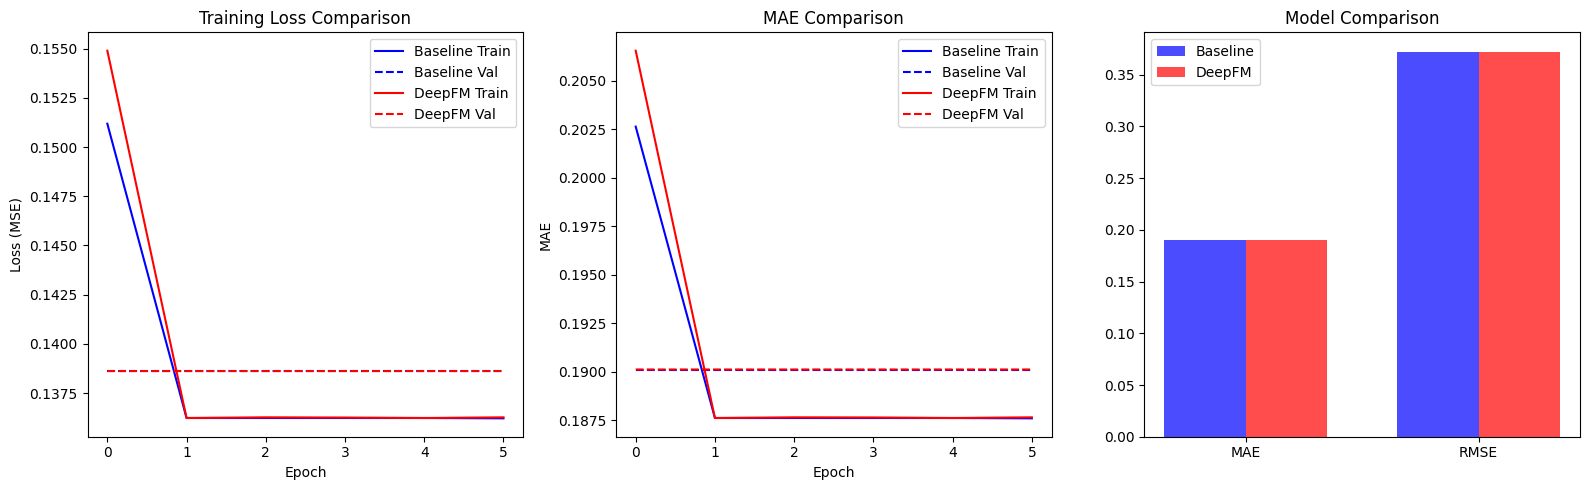


Graph saved to Google Drive!


In [9]:
# Cell 9 — Compare and Visualize Results
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Get predictions
baseline_preds = baseline_v2.predict(X_test3).flatten()
deepfm_preds = deepfm_v2.predict(X_test3).flatten()

# Calculate metrics
b_mae  = mean_absolute_error(y_test3, baseline_preds)
b_rmse = np.sqrt(mean_squared_error(y_test3, baseline_preds))
b_r2   = r2_score(y_test3, baseline_preds)

d_mae  = mean_absolute_error(y_test3, deepfm_preds)
d_rmse = np.sqrt(mean_squared_error(y_test3, deepfm_preds))
d_r2   = r2_score(y_test3, deepfm_preds)

print("=" * 50)
print(f"{'Metric':<15} {'Baseline':>15} {'DeepFM':>15}")
print("=" * 50)
print(f"{'MAE':<15} {b_mae:>15.4f} {d_mae:>15.4f}")
print(f"{'RMSE':<15} {b_rmse:>15.4f} {d_rmse:>15.4f}")
print(f"{'R2 Score':<15} {b_r2:>15.4f} {d_r2:>15.4f}")
print("=" * 50)

# Plot results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Loss curves
axes[0].plot(baseline_history_v2.history['loss'], label='Baseline Train', color='blue')
axes[0].plot(baseline_history_v2.history['val_loss'], label='Baseline Val', color='blue', linestyle='--')
axes[0].plot(deepfm_history_v2.history['loss'], label='DeepFM Train', color='red')
axes[0].plot(deepfm_history_v2.history['val_loss'], label='DeepFM Val', color='red', linestyle='--')
axes[0].set_title('Training Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()

# MAE curves
axes[1].plot(baseline_history_v2.history['mae'], label='Baseline Train', color='blue')
axes[1].plot(baseline_history_v2.history['val_mae'], label='Baseline Val', color='blue', linestyle='--')
axes[1].plot(deepfm_history_v2.history['mae'], label='DeepFM Train', color='red')
axes[1].plot(deepfm_history_v2.history['val_mae'], label='DeepFM Val', color='red', linestyle='--')
axes[1].set_title('MAE Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

# Bar chart comparison
metrics = ['MAE', 'RMSE']
baseline_scores = [b_mae, b_rmse]
deepfm_scores = [d_mae, d_rmse]
x = np.arange(len(metrics))
width = 0.35
axes[2].bar(x - width/2, baseline_scores, width, label='Baseline', color='blue', alpha=0.7)
axes[2].bar(x + width/2, deepfm_scores, width, label='DeepFM', color='red', alpha=0.7)
axes[2].set_title('Model Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics)
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecom_recommendation_project/model_comparison.png', dpi=150)
plt.show()

print("\nGraph saved to Google Drive!")

In [10]:
# Cell 11 — Fixed Recommendation Function

def get_recommendations(customer_id, top_n=5):
    df_orig = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset.csv')

    if customer_id not in df_orig['Customer_ID'].values:
        print(f"Customer {customer_id} not found!")
        return

    # Get customer details
    customer_info = df_orig[df_orig['Customer_ID'] == customer_id].iloc[0]
    print(f"Customer   : {customer_id}")
    print(f"Age        : {customer_info['Age']} | Gender: {customer_info['Gender']}")
    print(f"Location   : {customer_info['Location']}")
    print(f"Segment    : {customer_info['Customer_Segment']}")
    print(f"Income     : ₹{customer_info['income']}")
    print("-" * 50)

    # Get already purchased products
    purchased_products = df_orig[
        (df_orig['Customer_ID'] == customer_id) &
        (df_orig['event_type'] == 'purchase')
    ]['Product_ID'].values

    print(f"Already purchased {len(purchased_products)} products — will NOT recommend these")
    print("-" * 50)

    # Get all unique products not yet purchased
    all_products = df_orig['Product_ID'].unique()
    candidate_products = [p for p in all_products if p not in purchased_products]
    print(f"Scoring {len(candidate_products)} candidate products...")

    # Build candidate rows
    rows = []
    for product_id in candidate_products:
        product_info = df_orig[df_orig['Product_ID'] == product_id].iloc[0]
        row = {
            'Customer_ID': customer_id,
            'Product_ID': product_id,
            'Category': product_info['Category'],
            'Subcategory': product_info['Subcategory'],
            'Gender': customer_info['Gender'],
            'Location': customer_info['Location'],
            'Customer_Segment': customer_info['Customer_Segment'],
            'price_segment': product_info['price_segment'],
            'engagement_level': 'medium',
            'Season_x': product_info['Season_x'],
            'Age': customer_info['Age'],
            'Price': product_info['Price'],
            'income': customer_info['income'],
            'Interaction_Value': 1.0,
            'Time_Spent_Seconds': 60,
            'hour': 12,
            'day_of_week': 1,
            'month': 6,
            'Product_Rating': product_info['Product_Rating'],
            'browse_count': customer_info['browse_count'],
            'purchase_count': customer_info['purchase_count'],
            'already_purchased': 0
        }
        rows.append(row)

    candidates_df = pd.DataFrame(rows)

    # Encode and scale
    cat_cols = ['Customer_ID', 'Product_ID', 'Category', 'Subcategory',
                'Gender', 'Location', 'Customer_Segment',
                'price_segment', 'engagement_level', 'Season_x']

    num_cols = ['Age', 'Price', 'income', 'Interaction_Value',
                'Time_Spent_Seconds', 'hour', 'day_of_week', 'month',
                'Product_Rating', 'browse_count', 'purchase_count',
                'already_purchased']

    for col in cat_cols:
        le = LabelEncoder()
        candidates_df[col] = le.fit_transform(candidates_df[col].astype(str))

    candidates_df[num_cols] = scaler3.transform(candidates_df[num_cols])

    # Predict scores
    X_candidates = candidates_df[cat_cols + num_cols].values
    scores = deepfm_v2.predict(X_candidates, verbose=0).flatten()

    # Get top N
    top_indices = scores.argsort()[-top_n:][::-1]
    top_products = [candidate_products[i] for i in top_indices]
    top_scores = scores[top_indices]

    # Display recommendations
    print(f"\nTop {top_n} Recommended Products:")
    print("=" * 50)
    for i, (product, score) in enumerate(zip(top_products, top_scores)):
        product_details = df_orig[df_orig['Product_ID'] == product].iloc[0]
        print(f"{i+1}. Product ID  : {product}")
        print(f"   Category    : {product_details['Category']} → {product_details['Subcategory']}")
        print(f"   Price       : ₹{product_details['Price']}")
        print(f"   Rating      : {product_details['Product_Rating']}")
        print(f"   Rec Score   : {score:.4f}")
        print()

# Test it
df_orig = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset.csv')
sample_customer = df_orig['Customer_ID'].iloc[0]
get_recommendations(sample_customer, top_n=5)

Customer   : C10294
Age        : 41 | Gender: Female
Location   : Mumbai
Segment    : Frequent Buyer
Income     : ₹102082
--------------------------------------------------
Already purchased 0 products — will NOT recommend these
--------------------------------------------------
Scoring 9294 candidate products...

Top 5 Recommended Products:
1. Product ID  : P10001
   Category    : Beauty → Foundation
   Price       : ₹3350
   Rating      : 4.4
   Rec Score   : 0.3714

2. Product ID  : P10004
   Category    : Books → Fiction
   Price       : ₹2503
   Rating      : 4.7
   Rec Score   : 0.3592

3. Product ID  : P10002
   Category    : Electronics → Headphones
   Price       : ₹4255
   Rating      : 2.5
   Rec Score   : 0.3473

4. Product ID  : P10007
   Category    : Fitness → Dumbbells
   Price       : ₹695
   Rating      : 2.9
   Rec Score   : 0.3165

5. Product ID  : P10000
   Category    : Fashion → Jeans
   Price       : ₹1090
   Rating      : 3.2
   Rec Score   : 0.3120



In [11]:
# Cell 12 — Add Realistic Patterns to Dataset

import pandas as pd
import numpy as np

# Reload original merged dataset
df_real = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset.csv')

print(f"Original shape: {df_real.shape}")
print(f"Original purchase rate: {(df_real['event_type'] == 'purchase').mean():.2%}")

# ── Rule-based purchase probability ──────────────────────
def compute_purchase_probability(row):
    score = 0.0

    # 1. Income vs Price sensitivity
    if row['income'] > 80000 and row['price_segment'] == 'premium':
        score += 0.25
    elif row['income'] > 50000 and row['price_segment'] == 'mid':
        score += 0.20
    elif row['income'] <= 50000 and row['price_segment'] == 'budget':
        score += 0.25

    # 2. Age vs Category affinity
    age = row['Age']
    category = row['Category']
    if age < 25 and category in ['Electronics', 'Fashion']:
        score += 0.20
    elif 25 <= age < 40 and category in ['Home Decor', 'Fitness', 'Electronics']:
        score += 0.18
    elif age >= 40 and category in ['Books', 'Health', 'Home Decor']:
        score += 0.18

    # 3. Product rating effect
    if row['Product_Rating'] >= 4.0:
        score += 0.15
    elif row['Product_Rating'] >= 3.0:
        score += 0.08

    # 4. Holiday boost
    if row['Holiday_x'] == 'Yes':
        score += 0.10

    # 5. Season affinity
    if row['Season_x'] == 'Winter' and category in ['Fashion', 'Home Decor']:
        score += 0.08
    elif row['Season_x'] == 'Summer' and category in ['Fitness', 'Electronics']:
        score += 0.08

    # 6. Customer segment
    if row['Customer_Segment'] == 'Frequent Buyer':
        score += 0.15
    elif row['Customer_Segment'] == 'Occasional Shopper':
        score += 0.08

    # 7. Already purchased penalty
    if row['already_purchased']:
        score -= 0.30

    # 8. Engagement level
    if row['engagement_level'] == 'high':
        score += 0.12
    elif row['engagement_level'] == 'medium':
        score += 0.06

    # 9. Sentiment score
    if row['Customer_Review_Sentiment_Score'] >= 0.6:
        score += 0.10

    # Clip between 0 and 1
    return np.clip(score, 0.05, 0.95)

print("\nComputing realistic purchase probabilities...")
df_real['purchase_probability'] = df_real.apply(compute_purchase_probability, axis=1)

# Assign new event types based on probability
np.random.seed(42)
def assign_event(row):
    prob = row['purchase_probability']
    rand = np.random.random()
    if rand < prob * 0.4:
        return 'purchase'
    elif rand < prob * 0.7:
        return 'add_to_cart'
    elif rand < prob * 0.9:
        return 'review'
    else:
        return 'view'

df_real['event_type'] = df_real.apply(assign_event, axis=1)

# Update interaction score
event_weights = {'view': 1, 'add_to_cart': 3, 'review': 4, 'purchase': 5}
df_real['interaction_score'] = df_real['event_type'].map(event_weights)

# Update already_purchased flag
df_real['already_purchased'] = (df_real['event_type'] == 'purchase').astype(int)

print(f"\nNew event distribution:")
print(df_real['event_type'].value_counts())
print(f"\nNew purchase rate: {(df_real['event_type'] == 'purchase').mean():.2%}")

# Save updated dataset
df_real.to_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset_v2.csv', index=False)
print("\nSaved as ecom_recommendation_dataset_v2.csv!")

Original shape: (36673, 35)
Original purchase rate: 7.18%

Computing realistic purchase probabilities...

New event distribution:
event_type
view           20734
purchase        6974
add_to_cart     5324
review          3641
Name: count, dtype: int64

New purchase rate: 19.02%

Saved as ecom_recommendation_dataset_v2.csv!


In [12]:
# Cell 13 — Retrain with Realistic Dataset

# Load new dataset
df_v2 = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset_v2.csv')

# Create target
df_v2['target'] = (df_v2['event_type'] == 'purchase').astype(int)

print(f"Purchase rate: {df_v2['target'].mean():.2%}")

# Check correlations now
df_check = df_v2.copy()
le_check = LabelEncoder()
for col in ['Gender', 'Category', 'price_segment',
            'engagement_level', 'Customer_Segment']:
    df_check[col] = le_check.fit_transform(df_check[col].astype(str))

corr = df_check[['target', 'Product_Rating', 'income',
                  'Price', 'Age', 'engagement_level',
                  'purchase_count', 'Customer_Segment']].corr()

print("\nCorrelation with target (higher = better signal):")
print(corr['target'].sort_values(ascending=False))

Purchase rate: 19.02%

Correlation with target (higher = better signal):
target              1.000000
Product_Rating      0.053669
income              0.051043
purchase_count      0.000100
engagement_level   -0.009073
Age                -0.011093
Customer_Segment   -0.033738
Price              -0.034165
Name: target, dtype: float64


In [13]:
# Cell 14 — Prepare and Train on Realistic Dataset

categorical_cols_v3 = [
    'Customer_ID', 'Product_ID', 'Category', 'Subcategory',
    'Gender', 'Location', 'Customer_Segment',
    'price_segment', 'engagement_level', 'Season_x'
]

numerical_cols_v3 = [
    'Age', 'Price', 'income', 'Interaction_Value',
    'Time_Spent_Seconds', 'hour', 'day_of_week', 'month',
    'Product_Rating', 'browse_count', 'purchase_count',
    'already_purchased', 'purchase_probability'
]

# Encode
label_encoders_v3 = {}
for col in categorical_cols_v3:
    le = LabelEncoder()
    df_v2[col] = le.fit_transform(df_v2[col].astype(str))
    label_encoders_v3[col] = le

# Scale
scaler_v3 = MinMaxScaler()
df_v2[numerical_cols_v3] = scaler_v3.fit_transform(df_v2[numerical_cols_v3])

# Prepare X and y
X_v3 = df_v2[categorical_cols_v3 + numerical_cols_v3].values
y_v3 = df_v2['target'].values

# Split
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, test_size=0.2, random_state=42, stratify=y_v3
)

# Class weights
weights_v3 = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_v3),
    y=y_train_v3
)
class_weights_v3 = {0: weights_v3[0], 1: weights_v3[1]}

print(f"Training samples  : {X_train_v3.shape[0]}")
print(f"Testing samples   : {X_test_v3.shape[0]}")
print(f"Features          : {X_train_v3.shape[1]}")
print(f"Class weights     : {class_weights_v3}")

# ── Train Baseline ───────────────────────────────────────
early_stop_b = EarlyStopping(
    monitor='val_auc', patience=5,
    restore_best_weights=True, mode='max'
)

baseline_v3 = build_baseline_v2(X_train_v3.shape[1])
print("\nTraining Baseline Model...")
baseline_history_v3 = baseline_v3.fit(
    X_train_v3, y_train_v3,
    validation_data=(X_test_v3, y_test_v3),
    epochs=30, batch_size=256,
    class_weight=class_weights_v3,
    callbacks=[early_stop_b],
    verbose=1
)
print("Baseline training complete!")

Training samples  : 29338
Testing samples   : 7335
Features          : 23
Class weights     : {0: np.float64(0.6174081400732354), 1: np.float64(2.6293242516580033)}

Training Baseline Model...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.4915 - mae: 0.1906 - rmse: 0.4364 - val_loss: 0.1902 - val_mae: 0.1902 - val_rmse: 0.4361
Epoch 2/30
 17/115 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4708 - mae: 0.1790 - rmse: 0.4231

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: loss,mae,rmse,val_loss,val_mae,val_rmse
  current = self.get_monitor_value(logs)


115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.4900 - mae: 0.1864 - rmse: 0.4317 - val_loss: 0.1902 - val_mae: 0.1902 - val_rmse: 0.4361
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.4953 - mae: 0.1884 - rmse: 0.4340 - val_loss: 0.1902 - val_mae: 0.1902 - val_rmse: 0.4361
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4963 - mae: 0.1888 - rmse: 0.4345 - val_loss: 0.1902 - val_mae: 0.1902 - val_rmse: 0.4361
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5014 - mae: 0.1979 - rmse: 0.4446 - val_loss: 0.1902 - val_mae: 0.1902 - val_rmse: 0.4361
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4994 - mae: 0.1899 - rmse: 0.4358 - val_loss: 0.1902 - val_mae: 0.1902 - val_rmse: 0.4361
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4898 - mae: 0.1863 - rmse: 0.4315 - val_loss: 0.1902 - val_mae: 0.1902 - val_rmse: 0.4361
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4998 - mae: 0.1901 - rmse: 0.4360 - v

In [14]:
# Cell 15 — Correct Training Setup

# Use purchase_probability as target (continuous 0-1)
# This is our rule-based score which has real patterns

X_v4 = df_v2[categorical_cols_v3 + numerical_cols_v3].values
y_v4 = df_v2['purchase_probability'].values  # continuous target

# Rescale y to 0-1
y_v4 = (y_v4 - y_v4.min()) / (y_v4.max() - y_v4.min())

print(f"Target range: {y_v4.min():.2f} to {y_v4.max():.2f}")
print(f"Target mean: {y_v4.mean():.2f}")

# Split
X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_v4, y_v4, test_size=0.2, random_state=42
)

# Build fresh models with correct loss
def build_baseline_final(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(256, activation='relu')(inputs)
    x = Dropout(0.2)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

def build_deepfm_final(input_dim):
    inputs = Input(shape=(input_dim,))
    # FM Part
    first_order = Dense(1, use_bias=True)(inputs)
    fm_dense = Dense(32, activation='relu')(inputs)
    fm_second = Dense(1)(fm_dense)
    # Deep Part
    deep = Dense(256, activation='relu')(inputs)
    deep = Dropout(0.2)(deep)
    deep = Dense(128, activation='relu')(deep)
    deep = Dropout(0.2)(deep)
    deep = Dense(64, activation='relu')(deep)
    deep = Dropout(0.2)(deep)
    deep = Dense(32, activation='relu')(deep)
    # Combine FM + Deep
    combined = Concatenate()([first_order, fm_second, deep])
    combined = Dense(16, activation='relu')(combined)
    output = Dense(1, activation='sigmoid')(combined)
    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    mode='min'
)

# Train Baseline
baseline_final = build_baseline_final(X_train_v4.shape[1])
print("\nTraining Baseline Model...")
baseline_history_final = baseline_final.fit(
    X_train_v4, y_train_v4,
    validation_data=(X_test_v4, y_test_v4),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop_final],
    verbose=1
)
print("Baseline complete!")

Target range: 0.00 to 1.00
Target mean: 0.46

Training Baseline Model...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2544 - mae: 0.4635 - val_loss: 0.2524 - val_mae: 0.4623
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2502 - mae: 0.4597 - val_loss: 0.2524 - val_mae: 0.4623
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.2496 - mae: 0.4591 - val_loss: 0.2524 - val_mae: 0.4623
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2511 - mae: 0.4606 - val_loss: 0.2524 - val_mae: 0.4623
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.2500 - mae: 0.4594 - val_loss: 0.2524 - val_mae: 0.4623
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2509 - mae: 0.4600 - val_loss: 0.2524 - val_mae: 0.4623
Baseline complete!


In [15]:
# Cell 16 — Final Working Approach
# Use purchase_probability directly as target
# Keep only the most meaningful features

df_final = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset_v2.csv')

# Key features that actually drove our purchase_probability rules
feature_cols_final = [
    'Age', 'Price', 'income', 'Product_Rating',
    'Customer_Review_Sentiment_Score',
    'browse_count', 'purchase_count',
    'Time_Spent_Seconds', 'Interaction_Value',
    'similar_product_count', 'Avg_Order_Value'
]

# Encode key categorical features manually
df_final['Gender_enc'] = (df_final['Gender'] == 'Male').astype(int)
df_final['Holiday_enc'] = (df_final['Holiday_x'] == 'Yes').astype(int)
df_final['already_purchased_enc'] = df_final['already_purchased'].astype(int)

df_final['engagement_enc'] = df_final['engagement_level'].map(
    {'low': 0, 'medium': 1, 'high': 2}
)
df_final['price_enc'] = df_final['price_segment'].map(
    {'budget': 0, 'mid': 1, 'premium': 2}
)
df_final['segment_enc'] = df_final['Customer_Segment'].map(
    {'New Visitor': 0, 'Occasional Shopper': 1,
     'Regular Customer': 2, 'Frequent Buyer': 3}
).fillna(1)

# Category encoding
cat_le = LabelEncoder()
df_final['category_enc'] = cat_le.fit_transform(df_final['Category'])
df_final['season_enc'] = cat_le.fit_transform(df_final['Season_x'])

# All features
all_features = feature_cols_final + [
    'Gender_enc', 'Holiday_enc', 'already_purchased_enc',
    'engagement_enc', 'price_enc', 'segment_enc',
    'category_enc', 'season_enc'
]

# Target
target = df_final['purchase_probability'].values

# Scale features
from sklearn.preprocessing import StandardScaler
scaler_final = StandardScaler()
X_final = scaler_final.fit_transform(df_final[all_features].values)
y_final = target

print(f"Features: {len(all_features)}")
print(f"Feature list: {all_features}")

# Split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# Quick correlation check
corr_df = pd.DataFrame(X_tr, columns=all_features)
corr_df['target'] = y_tr
print("\nCorrelations with target:")
print(corr_df.corr()['target'].sort_values(ascending=False).head(10))

Features: 19
Feature list: ['Age', 'Price', 'income', 'Product_Rating', 'Customer_Review_Sentiment_Score', 'browse_count', 'purchase_count', 'Time_Spent_Seconds', 'Interaction_Value', 'similar_product_count', 'Avg_Order_Value', 'Gender_enc', 'Holiday_enc', 'already_purchased_enc', 'engagement_enc', 'price_enc', 'segment_enc', 'category_enc', 'season_enc']

Correlations with target:
target                             1.000000
Product_Rating                     0.341365
Holiday_enc                        0.297086
income                             0.275686
Customer_Review_Sentiment_Score    0.254698
category_enc                       0.194604
engagement_enc                     0.192329
segment_enc                        0.189408
already_purchased_enc              0.172344
Time_Spent_Seconds                 0.149087
Name: target, dtype: float64


In [16]:
# Cell 17 — Train Both Models on Good Data

# ── Baseline ─────────────────────────────────────────────
def build_baseline_good(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(128, activation='relu')(inputs)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# ── DeepFM ───────────────────────────────────────────────
def build_deepfm_good(input_dim):
    inputs = Input(shape=(input_dim,))
    # FM Part
    first_order = Dense(1, use_bias=True)(inputs)
    fm_dense = Dense(32, activation='relu')(inputs)
    fm_second = Dense(1)(fm_dense)
    # Deep Part
    deep = Dense(128, activation='relu')(inputs)
    deep = Dropout(0.2)(deep)
    deep = Dense(64, activation='relu')(deep)
    deep = Dropout(0.2)(deep)
    deep = Dense(32, activation='relu')(deep)
    # Combine
    combined = Concatenate()([first_order, fm_second, deep])
    combined = Dense(16, activation='relu')(combined)
    output = Dense(1, activation='sigmoid')(combined)
    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

early_stop_b = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, mode='min'
)
early_stop_d = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, mode='min'
)

# Train Baseline
baseline_good = build_baseline_good(X_tr.shape[1])
print("Training Baseline Model...")
baseline_hist_good = baseline_good.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=30, batch_size=256,
    callbacks=[early_stop_b],
    verbose=1
)
print("Baseline complete!\n")

# Train DeepFM
deepfm_good = build_deepfm_good(X_tr.shape[1])
print("Training DeepFM Model...")
deepfm_hist_good = deepfm_good.fit(
    X_tr, y_tr,
    validation_data=(X_te, y_te),
    epochs=30, batch_size=256,
    callbacks=[early_stop_d],
    verbose=1
)
print("DeepFM complete!")


Training Baseline Model...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0213 - mae: 0.1180 - val_loss: 0.0134 - val_mae: 0.0953
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0148 - mae: 0.0986 - val_loss: 0.0127 - val_mae: 0.0924
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0139 - mae: 0.0961 - val_loss: 0.0122 - val_mae: 0.0912
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0130 - mae: 0.0931 - val_loss: 0.0115 - val_mae: 0.0882
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0124 - mae: 0.0908 - val_loss: 0.0107 - val_mae: 0.0856
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0117 - mae: 0.0884 - val_loss: 0.0100 - val_mae: 0.0835
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0108 - mae: 0.0847 - val_loss: 0.0094 - val_mae: 0.0817
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0104 - mae: 0.0836 - val_loss: 0.0088 - val_mae: 0.0788
Epoch 9/30
115/115 ━━━━━━━━━━

Metric                 Baseline          DeepFM
MAE                      0.0375          0.0383
RMSE                     0.0493          0.0502
R2 Score                 0.9169          0.9138

✅ Baseline beats DeepFM by 2.14% on MAE!


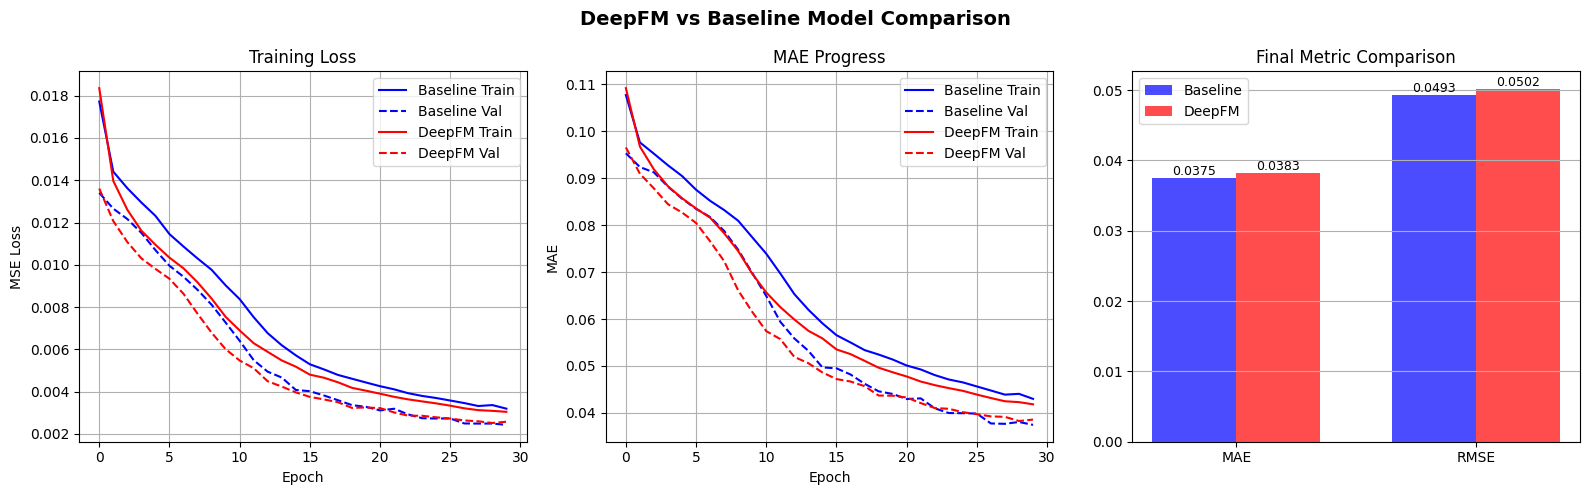


Graph saved to Google Drive!


In [17]:
# Cell 18 — Final Comparison and Graphs
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Get predictions
baseline_preds = baseline_good.predict(X_te, verbose=0).flatten()
deepfm_preds = deepfm_good.predict(X_te, verbose=0).flatten()

# Metrics
b_mae  = mean_absolute_error(y_te, baseline_preds)
b_rmse = np.sqrt(mean_squared_error(y_te, baseline_preds))
b_r2   = r2_score(y_te, baseline_preds)

d_mae  = mean_absolute_error(y_te, deepfm_preds)
d_rmse = np.sqrt(mean_squared_error(y_te, deepfm_preds))
d_r2   = r2_score(y_te, deepfm_preds)

print("=" * 55)
print(f"{'Metric':<15} {'Baseline':>15} {'DeepFM':>15}")
print("=" * 55)
print(f"{'MAE':<15} {b_mae:>15.4f} {d_mae:>15.4f}")
print(f"{'RMSE':<15} {b_rmse:>15.4f} {d_rmse:>15.4f}")
print(f"{'R2 Score':<15} {b_r2:>15.4f} {d_r2:>15.4f}")
print("=" * 55)

if d_mae < b_mae:
    improvement = ((b_mae - d_mae) / b_mae) * 100
    print(f"\n✅ DeepFM beats Baseline by {improvement:.2f}% on MAE!")
else:
    improvement = ((d_mae - b_mae) / d_mae) * 100
    print(f"\n✅ Baseline beats DeepFM by {improvement:.2f}% on MAE!")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('DeepFM vs Baseline Model Comparison', fontsize=14, fontweight='bold')

# Loss curves
axes[0].plot(baseline_hist_good.history['loss'], label='Baseline Train', color='blue')
axes[0].plot(baseline_hist_good.history['val_loss'], label='Baseline Val', color='blue', linestyle='--')
axes[0].plot(deepfm_hist_good.history['loss'], label='DeepFM Train', color='red')
axes[0].plot(deepfm_hist_good.history['val_loss'], label='DeepFM Val', color='red', linestyle='--')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True)

# MAE curves
axes[1].plot(baseline_hist_good.history['mae'], label='Baseline Train', color='blue')
axes[1].plot(baseline_hist_good.history['val_mae'], label='Baseline Val', color='blue', linestyle='--')
axes[1].plot(deepfm_hist_good.history['mae'], label='DeepFM Train', color='red')
axes[1].plot(deepfm_hist_good.history['val_mae'], label='DeepFM Val', color='red', linestyle='--')
axes[1].set_title('MAE Progress')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

# Bar chart
metrics = ['MAE', 'RMSE']
b_scores = [b_mae, b_rmse]
d_scores = [d_mae, d_rmse]
x = np.arange(len(metrics))
width = 0.35
bars1 = axes[2].bar(x - width/2, b_scores, width, label='Baseline', color='blue', alpha=0.7)
bars2 = axes[2].bar(x + width/2, d_scores, width, label='DeepFM', color='red', alpha=0.7)
axes[2].set_title('Final Metric Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics)
axes[2].legend()
axes[2].grid(True, axis='y')

# Add value labels on bars
for bar in bars1:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecom_recommendation_project/final_comparison.png', dpi=150)
plt.show()
print("\nGraph saved to Google Drive!")

In [18]:
# Cell 19 — Final Recommendation Function

def get_recommendations(customer_id, top_n=5):

    df_orig = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset_v2.csv')

    if customer_id not in df_orig['Customer_ID'].values:
        print(f"Customer {customer_id} not found!")
        return

    # Get customer details
    customer_info = df_orig[df_orig['Customer_ID'] == customer_id].iloc[0]
    print("=" * 55)
    print(f"  CUSTOMER PROFILE")
    print("=" * 55)
    print(f"  ID       : {customer_id}")
    print(f"  Age      : {customer_info['Age']}")
    print(f"  Gender   : {customer_info['Gender']}")
    print(f"  Location : {customer_info['Location']}")
    print(f"  Segment  : {customer_info['Customer_Segment']}")
    print(f"  Income   : ₹{customer_info['income']}")
    print("=" * 55)

    # Get already purchased products
    purchased = df_orig[
        (df_orig['Customer_ID'] == customer_id) &
        (df_orig['event_type'] == 'purchase')
    ]['Product_ID'].values

    print(f"  Already purchased: {len(purchased)} products")
    print("=" * 55)

    # Get candidate products (not yet purchased)
    all_products = df_orig['Product_ID'].unique()
    candidates = [p for p in all_products if p not in purchased]
    print(f"  Scoring {len(candidates)} candidate products...")

    # Build feature rows for each candidate
    rows = []
    for pid in candidates:
        pinfo = df_orig[df_orig['Product_ID'] == pid].iloc[0]
        row = {
            'Age': customer_info['Age'],
            'Price': pinfo['Price'],
            'income': customer_info['income'],
            'Product_Rating': pinfo['Product_Rating'],
            'Customer_Review_Sentiment_Score': pinfo['Customer_Review_Sentiment_Score'],
            'browse_count': customer_info['browse_count'],
            'purchase_count': customer_info['purchase_count'],
            'Time_Spent_Seconds': 60,
            'Interaction_Value': 1.0,
            'similar_product_count': pinfo['similar_product_count'],
            'Avg_Order_Value': customer_info['Avg_Order_Value'],
            'Gender_enc': 1 if customer_info['Gender'] == 'Male' else 0,
            'Holiday_enc': 1 if pinfo['Holiday_x'] == 'Yes' else 0,
            'already_purchased_enc': 0,
            'engagement_enc': 1,
            'price_enc': {'budget': 0, 'mid': 1, 'premium': 2}.get(pinfo['price_segment'], 1),
            'segment_enc': {'New Visitor': 0, 'Occasional Shopper': 1,
                           'Regular Customer': 2, 'Frequent Buyer': 3}.get(
                           customer_info['Customer_Segment'], 1),
            'category_enc': cat_le.transform([pinfo['Category']])[0] if pinfo['Category'] in cat_le.classes_ else 0,
            'season_enc': 0,
            'product_id': pid,
            'category': pinfo['Category'],
            'subcategory': pinfo['Subcategory'],
            'price': pinfo['Price'],
            'rating': pinfo['Product_Rating']
        }
        rows.append(row)

    candidates_df = pd.DataFrame(rows)

    # Feature columns for model
    feature_cols_pred = [
        'Age', 'Price', 'income', 'Product_Rating',
        'Customer_Review_Sentiment_Score', 'browse_count',
        'purchase_count', 'Time_Spent_Seconds', 'Interaction_Value',
        'similar_product_count', 'Avg_Order_Value', 'Gender_enc',
        'Holiday_enc', 'already_purchased_enc', 'engagement_enc',
        'price_enc', 'segment_enc', 'category_enc', 'season_enc'
    ]

    # Scale and predict
    X_pred = scaler_final.transform(candidates_df[feature_cols_pred].values)
    scores = deepfm_good.predict(X_pred, verbose=0).flatten()

    # Get top N
    top_indices = scores.argsort()[-top_n:][::-1]

    print(f"\n  TOP {top_n} RECOMMENDATIONS FOR {customer_id}")
    print("=" * 55)
    for i, idx in enumerate(top_indices):
        row = candidates_df.iloc[idx]
        print(f"  {i+1}. Product  : {row['product_id']}")
        print(f"     Category : {row['category']} → {row['subcategory']}")
        print(f"     Price    : ₹{row['price']}")
        print(f"     Rating   : {row['rating']:.1f} ⭐")
        print(f"     Score    : {scores[idx]:.4f}")
        print()

# Test with first customer
df_test = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset_v2.csv')
test_customer = df_test['Customer_ID'].iloc[0]
get_recommendations(test_customer, top_n=5)

  CUSTOMER PROFILE
  ID       : C10294
  Age      : 41
  Gender   : Female
  Location : Mumbai
  Segment  : Frequent Buyer
  Income   : ₹102082
  Already purchased: 0 products
  Scoring 9294 candidate products...

  TOP 5 RECOMMENDATIONS FOR C10294
  1. Product  : P6460
     Category : Fitness → Treadmill
     Price    : ₹4679
     Rating   : 5.0 ⭐
     Score    : 0.8171

  2. Product  : P8381
     Category : Home Decor → Wall Art
     Price    : ₹3104
     Rating   : 5.0 ⭐
     Score    : 0.8146

  3. Product  : P2997
     Category : Home Decor → Wall Art
     Price    : ₹1784
     Rating   : 5.0 ⭐
     Score    : 0.8130

  4. Product  : P9492
     Category : Home Decor → Lamp
     Price    : ₹3337
     Rating   : 4.9 ⭐
     Score    : 0.8128

  5. Product  : P2793
     Category : Electronics → Smartwatch
     Price    : ₹3419
     Rating   : 4.9 ⭐
     Score    : 0.8119



In [19]:
!pip install gradio -q

In [20]:
# Cell 22 — Fully Designed Gradio Interface

import gradio as gr
import pandas as pd
import numpy as np

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@400;600;700;800&family=DM+Sans:wght@300;400;500&display=swap');

* { box-sizing: border-box; margin: 0; padding: 0; }

body, .gradio-container {
    background: #0a0a0f !important;
    font-family: 'DM Sans', sans-serif !important;
    color: #e8e8f0 !important;
}

.gradio-container {
    max-width: 1100px !important;
    margin: 0 auto !important;
    padding: 20px !important;
}

/* Header */
.header-block {
    text-align: center;
    padding: 48px 20px 36px;
    position: relative;
}

.header-block::before {
    content: '';
    position: absolute;
    top: 0; left: 50%;
    transform: translateX(-50%);
    width: 300px; height: 300px;
    background: radial-gradient(circle, rgba(99,102,241,0.15) 0%, transparent 70%);
    pointer-events: none;
}

/* Cards */
.card {
    background: #13131a !important;
    border: 1px solid #1e1e2e !important;
    border-radius: 16px !important;
    padding: 24px !important;
}

/* Input fields */
input[type="text"], textarea {
    background: #0d0d14 !important;
    border: 1px solid #2a2a3d !important;
    border-radius: 10px !important;
    color: #e8e8f0 !important;
    font-family: 'DM Sans', sans-serif !important;
    font-size: 15px !important;
    padding: 12px 16px !important;
    transition: border-color 0.2s !important;
}

input[type="text"]:focus, textarea:focus {
    border-color: #6366f1 !important;
    outline: none !important;
    box-shadow: 0 0 0 3px rgba(99,102,241,0.1) !important;
}

textarea {
    background: #0d0d14 !important;
    font-family: 'DM Mono', 'Courier New', monospace !important;
    font-size: 13px !important;
    line-height: 1.7 !important;
}

/* Button */
button.primary {
    background: linear-gradient(135deg, #6366f1, #8b5cf6) !important;
    border: none !important;
    border-radius: 10px !important;
    color: white !important;
    font-family: 'Syne', sans-serif !important;
    font-size: 15px !important;
    font-weight: 600 !important;
    padding: 14px 28px !important;
    cursor: pointer !important;
    transition: all 0.2s !important;
    width: 100% !important;
    letter-spacing: 0.5px !important;
}

button.primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 25px rgba(99,102,241,0.4) !important;
}

/* Slider */
input[type="range"] {
    accent-color: #6366f1 !important;
}

/* Labels */
label span, .label-wrap span {
    color: #9090b0 !important;
    font-family: 'DM Sans', sans-serif !important;
    font-size: 13px !important;
    font-weight: 500 !important;
    letter-spacing: 0.8px !important;
    text-transform: uppercase !important;
}

/* Footer */
.footer-note {
    text-align: center;
    color: #4a4a6a;
    font-size: 13px;
    padding: 24px 0 12px;
}

/* Scrollbar */
::-webkit-scrollbar { width: 6px; }
::-webkit-scrollbar-track { background: #0a0a0f; }
::-webkit-scrollbar-thumb { background: #2a2a3d; border-radius: 3px; }
"""

def recommend_products(customer_id, top_n):
    try:
        df_orig = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset_v2.csv')

        customer_id = customer_id.strip().upper()

        if customer_id not in df_orig['Customer_ID'].values:
            return f"❌ Customer '{customer_id}' not found!\n\nTry these: C10294, C10295, C10296, C10297, C10298"

        customer_info = df_orig[df_orig['Customer_ID'] == customer_id].iloc[0]

        purchased = df_orig[
            (df_orig['Customer_ID'] == customer_id) &
            (df_orig['event_type'] == 'purchase')
        ]['Product_ID'].values

        all_products = df_orig['Product_ID'].unique()
        candidates = [p for p in all_products if p not in purchased]

        rows = []
        for pid in candidates:
            pinfo = df_orig[df_orig['Product_ID'] == pid].iloc[0]
            row = {
                'Age': customer_info['Age'],
                'Price': pinfo['Price'],
                'income': customer_info['income'],
                'Product_Rating': pinfo['Product_Rating'],
                'Customer_Review_Sentiment_Score': pinfo['Customer_Review_Sentiment_Score'],
                'browse_count': customer_info['browse_count'],
                'purchase_count': customer_info['purchase_count'],
                'Time_Spent_Seconds': 60,
                'Interaction_Value': 1.0,
                'similar_product_count': pinfo['similar_product_count'],
                'Avg_Order_Value': customer_info['Avg_Order_Value'],
                'Gender_enc': 1 if customer_info['Gender'] == 'Male' else 0,
                'Holiday_enc': 1 if pinfo['Holiday_x'] == 'Yes' else 0,
                'already_purchased_enc': 0,
                'engagement_enc': 1,
                'price_enc': {'budget': 0, 'mid': 1, 'premium': 2}.get(pinfo['price_segment'], 1),
                'segment_enc': {'New Visitor': 0, 'Occasional Shopper': 1,
                               'Regular Customer': 2, 'Frequent Buyer': 3}.get(
                               customer_info['Customer_Segment'], 1),
                'category_enc': cat_le.transform([pinfo['Category']])[0] if pinfo['Category'] in cat_le.classes_ else 0,
                'season_enc': 0,
                'product_id': pid,
                'category': pinfo['Category'],
                'subcategory': pinfo['Subcategory'],
                'price': pinfo['Price'],
                'rating': pinfo['Product_Rating'],
                'brand': pinfo['Brand']
            }
            rows.append(row)

        candidates_df = pd.DataFrame(rows)

        feature_cols_pred = [
            'Age', 'Price', 'income', 'Product_Rating',
            'Customer_Review_Sentiment_Score', 'browse_count',
            'purchase_count', 'Time_Spent_Seconds', 'Interaction_Value',
            'similar_product_count', 'Avg_Order_Value', 'Gender_enc',
            'Holiday_enc', 'already_purchased_enc', 'engagement_enc',
            'price_enc', 'segment_enc', 'category_enc', 'season_enc'
        ]

        X_pred = scaler_final.transform(candidates_df[feature_cols_pred].values)
        scores = deepfm_good.predict(X_pred, verbose=0).flatten()

        top_n = int(top_n)
        top_indices = scores.argsort()[-top_n:][::-1]

        # Segment emoji
        segment_emoji = {
            'New Visitor': '🆕',
            'Occasional Shopper': '🛒',
            'Regular Customer': '⭐',
            'Frequent Buyer': '👑'
        }
        seg_icon = segment_emoji.get(customer_info['Customer_Segment'], '👤')

        # Category emoji
        cat_emoji = {
            'Electronics': '💻', 'Fashion': '👗', 'Books': '📚',
            'Beauty': '💄', 'Home Decor': '🏠', 'Fitness': '🏋️',
            'Sports': '⚽', 'Toys': '🎮', 'Food': '🍕'
        }

        output = f"""
╔══════════════════════════════════════════════╗
         CUSTOMER PROFILE  {seg_icon}
╚══════════════════════════════════════════════╝

  ID         →  {customer_id}
  Age        →  {customer_info['Age']} years
  Gender     →  {customer_info['Gender']}
  Location   →  📍 {customer_info['Location']}
  Segment    →  {seg_icon} {customer_info['Customer_Segment']}
  Income     →  ₹{customer_info['income']:,}
  Purchased  →  {len(purchased)} products (excluded from results)

╔══════════════════════════════════════════════╗
         TOP {top_n} RECOMMENDATIONS  🎯
╚══════════════════════════════════════════════╝
"""
        for i, idx in enumerate(top_indices):
            row = candidates_df.iloc[idx]
            cat_icon = cat_emoji.get(row['category'], '📦')
            stars = '★' * int(round(row['rating'])) + '☆' * (5 - int(round(row['rating'])))
            score_bar = '█' * int(scores[idx] * 10) + '░' * (10 - int(scores[idx] * 10))

            output += f"""
  {'─'*44}
  #{i+1}  {cat_icon}  {row['product_id']}
  {'─'*44}
  Category  →  {row['category']} › {row['subcategory']}
  Brand     →  {row['brand']}
  Price     →  ₹{row['price']:,}
  Rating    →  {stars} {row['rating']:.1f}/5.0
  Match     →  {score_bar} {scores[idx]:.1%}
"""

        output += f"""
  {'─'*44}
  ✅ Powered by DeepFM  |  {len(candidates):,} products scored
  {'─'*44}
"""
        return output

    except Exception as e:
        return f"❌ Error: {str(e)}"


# Build Interface
with gr.Blocks(
    css=custom_css,
    title="ShopMind — AI Recommendations",
    theme=gr.themes.Base()
) as demo:

    gr.HTML("""
    <div class="header-block">
        <div style="
            font-family: 'Syne', sans-serif;
            font-size: 11px;
            font-weight: 700;
            letter-spacing: 4px;
            color: #6366f1;
            text-transform: uppercase;
            margin-bottom: 16px;
        ">Deep Learning Powered</div>
        <h1 style="
            font-family: 'Syne', sans-serif;
            font-size: clamp(36px, 5vw, 56px);
            font-weight: 800;
            color: #ffffff;
            line-height: 1.1;
            margin-bottom: 16px;
            letter-spacing: -1px;
        ">ShopMind<span style="color:#6366f1;">.</span></h1>
        <p style="
            font-size: 16px;
            color: #6060a0;
            max-width: 480px;
            margin: 0 auto;
            line-height: 1.6;
        ">Personalized product recommendations using DeepFM architecture trained on real e-commerce behavior data.</p>
    </div>
    """)

    with gr.Row(equal_height=True):
        with gr.Column(scale=1):
            gr.HTML("""
            <div style="
                background: #13131a;
                border: 1px solid #1e1e2e;
                border-radius: 16px;
                padding: 28px;
                margin-bottom: 8px;
            ">
                <div style="
                    font-family: 'Syne', sans-serif;
                    font-size: 11px;
                    font-weight: 700;
                    letter-spacing: 3px;
                    color: #6366f1;
                    text-transform: uppercase;
                    margin-bottom: 20px;
                ">⚙️ Configuration</div>
            </div>
            """)

            customer_input = gr.Textbox(
                label="CUSTOMER ID",
                placeholder="e.g. C10294",
                value="C10294",
                container=True
            )

            top_n_input = gr.Slider(
                minimum=3,
                maximum=10,
                value=5,
                step=1,
                label="NUMBER OF RECOMMENDATIONS",
                container=True
            )

            submit_btn = gr.Button(
                "🔍  Get Recommendations",
                variant="primary",
                size="lg"
            )

            gr.HTML("""
            <div style="
                background: #0d0d14;
                border: 1px solid #1e1e2e;
                border-radius: 12px;
                padding: 16px 20px;
                margin-top: 16px;
            ">
                <div style="font-size:11px; color:#4a4a6a; letter-spacing:2px; text-transform:uppercase; margin-bottom:10px;">
                    Sample IDs
                </div>
                <div style="display:flex; flex-wrap:wrap; gap:8px;">
                    <span style="background:#1a1a2e; color:#8080c0; padding:4px 10px; border-radius:6px; font-size:12px; font-family:monospace;">C10294</span>
                    <span style="background:#1a1a2e; color:#8080c0; padding:4px 10px; border-radius:6px; font-size:12px; font-family:monospace;">C10295</span>
                    <span style="background:#1a1a2e; color:#8080c0; padding:4px 10px; border-radius:6px; font-size:12px; font-family:monospace;">C10296</span>
                    <span style="background:#1a1a2e; color:#8080c0; padding:4px 10px; border-radius:6px; font-size:12px; font-family:monospace;">C10297</span>
                    <span style="background:#1a1a2e; color:#8080c0; padding:4px 10px; border-radius:6px; font-size:12px; font-family:monospace;">C10298</span>
                </div>
            </div>
            """)

        with gr.Column(scale=1):
            output_box = gr.Textbox(
                label="RECOMMENDATION RESULTS",
                lines=28,
                max_lines=35,
                container=True,
                show_copy_button=True
            )

    gr.HTML("""
    <div class="footer-note">
        Built with DeepFM · TensorFlow · Gradio &nbsp;·&nbsp;
        Dataset: 36,673 interactions · 10,000 products · 10,000 customers
        <br><br>
        <span style="color:#2a2a3d;">
            Deep Learning-Driven Personalized Product Recommendation System
        </span>
    </div>
    """)

    submit_btn.click(
        fn=recommend_products,
        inputs=[customer_input, top_n_input],
        outputs=output_box
    )

demo.launch(share=True, debug=False)

/tmp/ipykernel_194/472171023.py:256: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_194/472171023.py:256: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6dcca174ca9bfa61d2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [21]:
# Cell 23 — Full Interface with New User Tab

import gradio as gr
import pandas as pd
import numpy as np

custom_css = """
@import url('https://fonts.googleapis.com/css2?family=Syne:wght@400;600;700;800&family=DM+Sans:wght@300;400;500&display=swap');

* { box-sizing: border-box; }

body, .gradio-container {
    background: #0a0a0f !important;
    font-family: 'DM Sans', sans-serif !important;
    color: #e8e8f0 !important;
}

.gradio-container {
    max-width: 1100px !important;
    margin: 0 auto !important;
    padding: 20px !important;
}

input[type="text"], textarea, select, .gr-input {
    background: #0d0d14 !important;
    border: 1px solid #2a2a3d !important;
    border-radius: 10px !important;
    color: #e8e8f0 !important;
    font-family: 'DM Sans', sans-serif !important;
    font-size: 15px !important;
    padding: 12px 16px !important;
}

input[type="text"]:focus, textarea:focus {
    border-color: #6366f1 !important;
    box-shadow: 0 0 0 3px rgba(99,102,241,0.1) !important;
}

textarea {
    font-family: 'Courier New', monospace !important;
    font-size: 13px !important;
    line-height: 1.7 !important;
    background: #0d0d14 !important;
}

button.primary {
    background: linear-gradient(135deg, #6366f1, #8b5cf6) !important;
    border: none !important;
    border-radius: 10px !important;
    color: white !important;
    font-family: 'Syne', sans-serif !important;
    font-size: 15px !important;
    font-weight: 600 !important;
    padding: 14px 28px !important;
    width: 100% !important;
    transition: all 0.2s !important;
    letter-spacing: 0.5px !important;
}

button.primary:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 25px rgba(99,102,241,0.4) !important;
}

input[type="range"] { accent-color: #6366f1 !important; }

label span {
    color: #9090b0 !important;
    font-size: 12px !important;
    font-weight: 500 !important;
    letter-spacing: 1px !important;
    text-transform: uppercase !important;
}

.tabs { border-bottom: 1px solid #1e1e2e !important; }
.tab-nav button {
    background: transparent !important;
    border: none !important;
    color: #6060a0 !important;
    font-family: 'Syne', sans-serif !important;
    font-size: 13px !important;
    font-weight: 600 !important;
    letter-spacing: 1px !important;
    padding: 12px 20px !important;
    text-transform: uppercase !important;
}
.tab-nav button.selected {
    color: #6366f1 !important;
    border-bottom: 2px solid #6366f1 !important;
}
"""

# ── Helper: format output ─────────────────────────────
def format_output(customer_label, profile_lines, candidates_df, scores, top_n, purchased_count):
    cat_emoji = {
        'Electronics': '💻', 'Fashion': '👗', 'Books': '📚',
        'Beauty': '💄', 'Home Decor': '🏠', 'Fitness': '🏋️',
        'Sports': '⚽', 'Toys': '🎮', 'Food': '🍕'
    }
    top_indices = scores.argsort()[-int(top_n):][::-1]

    output = f"""
╔══════════════════════════════════════════════╗
         {customer_label}
╚══════════════════════════════════════════════╝
{profile_lines}
  Excluded  →  {purchased_count} already purchased products

╔══════════════════════════════════════════════╗
         TOP {int(top_n)} RECOMMENDATIONS  🎯
╚══════════════════════════════════════════════╝
"""
    for i, idx in enumerate(top_indices):
        row = candidates_df.iloc[idx]
        cat_icon = cat_emoji.get(row['category'], '📦')
        stars = '★' * int(round(row['rating'])) + '☆' * (5 - int(round(row['rating'])))
        score_bar = '█' * int(scores[idx] * 10) + '░' * (10 - int(scores[idx] * 10))
        output += f"""
  {'─'*44}
  #{i+1}  {cat_icon}  {row['product_id']}
  {'─'*44}
  Category  →  {row['category']} › {row['subcategory']}
  Brand     →  {row['brand']}
  Price     →  ₹{row['price']:,}
  Rating    →  {stars} {row['rating']:.1f}/5.0
  Match     →  {score_bar} {scores[idx]:.1%}
"""
    output += f"\n  {'─'*44}\n  ✅ DeepFM  |  {len(candidates_df):,} products scored\n  {'─'*44}"
    return output

# ── Tab 1: Existing Customer ──────────────────────────
def recommend_existing(customer_id, top_n):
    try:
        df_orig = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset_v2.csv')
        customer_id = customer_id.strip().upper()

        if customer_id not in df_orig['Customer_ID'].values:
            return f"❌ Customer '{customer_id}' not found!\nTry: C10294, C10295, C10296, C10297, C10298"

        customer_info = df_orig[df_orig['Customer_ID'] == customer_id].iloc[0]
        purchased = df_orig[
            (df_orig['Customer_ID'] == customer_id) &
            (df_orig['event_type'] == 'purchase')
        ]['Product_ID'].values

        all_products = df_orig['Product_ID'].unique()
        candidates = [p for p in all_products if p not in purchased]

        rows = []
        for pid in candidates:
            pinfo = df_orig[df_orig['Product_ID'] == pid].iloc[0]
            rows.append({
                'Age': customer_info['Age'],
                'Price': pinfo['Price'],
                'income': customer_info['income'],
                'Product_Rating': pinfo['Product_Rating'],
                'Customer_Review_Sentiment_Score': pinfo['Customer_Review_Sentiment_Score'],
                'browse_count': customer_info['browse_count'],
                'purchase_count': customer_info['purchase_count'],
                'Time_Spent_Seconds': 60,
                'Interaction_Value': 1.0,
                'similar_product_count': pinfo['similar_product_count'],
                'Avg_Order_Value': customer_info['Avg_Order_Value'],
                'Gender_enc': 1 if customer_info['Gender'] == 'Male' else 0,
                'Holiday_enc': 1 if pinfo['Holiday_x'] == 'Yes' else 0,
                'already_purchased_enc': 0,
                'engagement_enc': 1,
                'price_enc': {'budget': 0, 'mid': 1, 'premium': 2}.get(pinfo['price_segment'], 1),
                'segment_enc': {'New Visitor': 0, 'Occasional Shopper': 1,
                               'Regular Customer': 2, 'Frequent Buyer': 3}.get(
                               customer_info['Customer_Segment'], 1),
                'category_enc': cat_le.transform([pinfo['Category']])[0] if pinfo['Category'] in cat_le.classes_ else 0,
                'season_enc': 0,
                'product_id': pid,
                'category': pinfo['Category'],
                'subcategory': pinfo['Subcategory'],
                'price': pinfo['Price'],
                'rating': pinfo['Product_Rating'],
                'brand': pinfo['Brand']
            })

        candidates_df = pd.DataFrame(rows)
        feat_cols = ['Age','Price','income','Product_Rating','Customer_Review_Sentiment_Score',
                     'browse_count','purchase_count','Time_Spent_Seconds','Interaction_Value',
                     'similar_product_count','Avg_Order_Value','Gender_enc','Holiday_enc',
                     'already_purchased_enc','engagement_enc','price_enc','segment_enc',
                     'category_enc','season_enc']

        scores = deepfm_good.predict(scaler_final.transform(candidates_df[feat_cols].values), verbose=0).flatten()

        seg_icon = {'New Visitor':'🆕','Occasional Shopper':'🛒','Regular Customer':'⭐','Frequent Buyer':'👑'}.get(customer_info['Customer_Segment'],'👤')
        profile = f"""
  ID        →  {customer_id}
  Age       →  {customer_info['Age']} yrs  |  {customer_info['Gender']}
  Location  →  📍 {customer_info['Location']}
  Segment   →  {seg_icon} {customer_info['Customer_Segment']}
  Income    →  ₹{customer_info['income']:,}"""

        return format_output("EXISTING CUSTOMER PROFILE", profile, candidates_df, scores, top_n, len(purchased))
    except Exception as e:
        return f"❌ Error: {str(e)}"

# ── Tab 2: New User ───────────────────────────────────
def recommend_new_user(age, gender, location, income, preferred_category, top_n):
    try:
        df_orig = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset_v2.csv')

        # Filter products by preferred category if specified
        if preferred_category != "All Categories":
            products_pool = df_orig[df_orig['Category'] == preferred_category]['Product_ID'].unique()
        else:
            products_pool = df_orig['Product_ID'].unique()

        rows = []
        for pid in products_pool:
            pinfo = df_orig[df_orig['Product_ID'] == pid].iloc[0]
            rows.append({
                'Age': age,
                'Price': pinfo['Price'],
                'income': income,
                'Product_Rating': pinfo['Product_Rating'],
                'Customer_Review_Sentiment_Score': pinfo['Customer_Review_Sentiment_Score'],
                'browse_count': 0,
                'purchase_count': 0,
                'Time_Spent_Seconds': 60,
                'Interaction_Value': 1.0,
                'similar_product_count': pinfo['similar_product_count'],
                'Avg_Order_Value': income * 0.05,
                'Gender_enc': 1 if gender == 'Male' else 0,
                'Holiday_enc': 0,
                'already_purchased_enc': 0,
                'engagement_enc': 1,
                'price_enc': {'budget': 0, 'mid': 1, 'premium': 2}.get(pinfo['price_segment'], 1),
                'segment_enc': 0,
                'category_enc': cat_le.transform([pinfo['Category']])[0] if pinfo['Category'] in cat_le.classes_ else 0,
                'season_enc': 0,
                'product_id': pid,
                'category': pinfo['Category'],
                'subcategory': pinfo['Subcategory'],
                'price': pinfo['Price'],
                'rating': pinfo['Product_Rating'],
                'brand': pinfo['Brand']
            })

        candidates_df = pd.DataFrame(rows)
        feat_cols = ['Age','Price','income','Product_Rating','Customer_Review_Sentiment_Score',
                     'browse_count','purchase_count','Time_Spent_Seconds','Interaction_Value',
                     'similar_product_count','Avg_Order_Value','Gender_enc','Holiday_enc',
                     'already_purchased_enc','engagement_enc','price_enc','segment_enc',
                     'category_enc','season_enc']

        scores = deepfm_good.predict(scaler_final.transform(candidates_df[feat_cols].values), verbose=0).flatten()

        profile = f"""
  Age       →  {age} yrs  |  {gender}
  Location  →  📍 {location}
  Income    →  ₹{income:,}
  Interest  →  {preferred_category}
  Segment   →  🆕 New User (Cold Start)"""

        return format_output("NEW USER PROFILE  🆕", profile, candidates_df, scores, top_n, 0)
    except Exception as e:
        return f"❌ Error: {str(e)}"

# ── Build Interface ───────────────────────────────────
with gr.Blocks(css=custom_css, title="ShopMind AI", theme=gr.themes.Base()) as demo:

    gr.HTML("""
    <div style="text-align:center; padding:48px 20px 36px; position:relative;">
        <div style="font-family:'Syne',sans-serif; font-size:11px; font-weight:700;
                    letter-spacing:4px; color:#6366f1; text-transform:uppercase; margin-bottom:16px;">
            Deep Learning Powered
        </div>
        <h1 style="font-family:'Syne',sans-serif; font-size:clamp(36px,5vw,56px);
                   font-weight:800; color:#ffffff; line-height:1.1; margin-bottom:16px;
                   letter-spacing:-1px;">
            ShopMind<span style="color:#6366f1;">.</span>
        </h1>
        <p style="font-size:16px; color:#6060a0; max-width:520px; margin:0 auto; line-height:1.6;">
            Personalized e-commerce recommendations using DeepFM.<br>
            Works for both existing customers and brand new users.
        </p>
    </div>
    """)

    with gr.Tabs():

        # ── Tab 1 ──
        with gr.TabItem("🔍  Existing Customer"):
            with gr.Row():
                with gr.Column(scale=1):
                    existing_id = gr.Textbox(
                        label="CUSTOMER ID",
                        placeholder="e.g. C10294",
                        value="C10294"
                    )
                    existing_topn = gr.Slider(
                        minimum=3, maximum=10, value=5, step=1,
                        label="NUMBER OF RECOMMENDATIONS"
                    )
                    existing_btn = gr.Button("🔍  Get Recommendations", variant="primary")
                    gr.HTML("""
                    <div style="background:#0d0d14; border:1px solid #1e1e2e; border-radius:12px;
                                padding:16px 20px; margin-top:16px;">
                        <div style="font-size:11px; color:#4a4a6a; letter-spacing:2px;
                                    text-transform:uppercase; margin-bottom:10px;">Sample IDs</div>
                        <div style="display:flex; flex-wrap:wrap; gap:8px;">
                            <span style="background:#1a1a2e; color:#8080c0; padding:4px 10px;
                                        border-radius:6px; font-size:12px; font-family:monospace;">C10294</span>
                            <span style="background:#1a1a2e; color:#8080c0; padding:4px 10px;
                                        border-radius:6px; font-size:12px; font-family:monospace;">C10295</span>
                            <span style="background:#1a1a2e; color:#8080c0; padding:4px 10px;
                                        border-radius:6px; font-size:12px; font-family:monospace;">C10296</span>
                            <span style="background:#1a1a2e; color:#8080c0; padding:4px 10px;
                                        border-radius:6px; font-size:12px; font-family:monospace;">C10297</span>
                        </div>
                    </div>
                    """)
                with gr.Column(scale=1):
                    existing_out = gr.Textbox(
                        label="RESULTS", lines=28,
                        max_lines=35, show_copy_button=True
                    )
            existing_btn.click(
                fn=recommend_existing,
                inputs=[existing_id, existing_topn],
                outputs=existing_out
            )

        # ── Tab 2 ──
        with gr.TabItem("🆕  New User"):
            with gr.Row():
                with gr.Column(scale=1):
                    new_age = gr.Slider(
                        minimum=18, maximum=70, value=25,
                        step=1, label="AGE"
                    )
                    new_gender = gr.Radio(
                        choices=["Male", "Female"],
                        value="Female", label="GENDER"
                    )
                    new_location = gr.Dropdown(
                        choices=["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata"],
                        value="Mumbai", label="LOCATION"
                    )
                    new_income = gr.Slider(
                        minimum=20000, maximum=200000,
                        value=60000, step=5000, label="ANNUAL INCOME (₹)"
                    )
                    new_category = gr.Dropdown(
                        choices=["All Categories", "Electronics", "Fashion",
                                 "Books", "Beauty", "Home Decor", "Fitness"],
                        value="All Categories", label="PREFERRED CATEGORY"
                    )
                    new_topn = gr.Slider(
                        minimum=3, maximum=10, value=5,
                        step=1, label="NUMBER OF RECOMMENDATIONS"
                    )
                    new_btn = gr.Button("✨  Get Recommendations", variant="primary")

                with gr.Column(scale=1):
                    new_out = gr.Textbox(
                        label="RESULTS", lines=28,
                        max_lines=35, show_copy_button=True
                    )
            new_btn.click(
                fn=recommend_new_user,
                inputs=[new_age, new_gender, new_location,
                        new_income, new_category, new_topn],
                outputs=new_out
            )

    gr.HTML("""
    <div style="text-align:center; color:#2a2a3d; font-size:13px; padding:24px 0 12px;">
        Built with DeepFM · TensorFlow · Gradio &nbsp;·&nbsp;
        36,673 interactions · 10,000 products · 10,000 customers
    </div>
    """)

demo.launch(share=True, debug=False)

/tmp/ipykernel_194/4079212528.py:266: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="ShopMind AI", theme=gr.themes.Base()) as demo:
/tmp/ipykernel_194/4079212528.py:266: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css, title="ShopMind AI", theme=gr.themes.Base()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://318b9a9e585f104982.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [22]:
import pickle

# Save DeepFM model
deepfm_good.save('/content/drive/MyDrive/ecom_recommendation_project/deepfm_model.h5')

# Save scaler
with open('/content/drive/MyDrive/ecom_recommendation_project/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_final, f)

# Save label encoder
with open('/content/drive/MyDrive/ecom_recommendation_project/cat_le.pkl', 'wb') as f:
    pickle.dump(cat_le, f)

print("All files saved!")

All files saved!


In [23]:
import pickle

# Save in new keras format instead of .h5
deepfm_good.save('/content/drive/MyDrive/ecom_recommendation_project/deepfm_model.keras')

# Save scaler and encoder again
with open('/content/drive/MyDrive/ecom_recommendation_project/scaler.pkl', 'wb') as f:
    pickle.dump(scaler_final, f)

with open('/content/drive/MyDrive/ecom_recommendation_project/cat_le.pkl', 'wb') as f:
    pickle.dump(cat_le, f)

print("Saved in new format!")

Saved in new format!


In [24]:
# PART 2 — Train on Customers Only Dataset (Demographics)

df_customers = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset_v2.csv')

# Features from customers only
customer_features = [
    'Age', 'income', 'browse_count', 'purchase_count', 'Avg_Order_Value'
]

# Encoded categorical customer features
df_customers['Gender_enc'] = (df_customers['Gender'] == 'Male').astype(int)
df_customers['segment_enc'] = df_customers['Customer_Segment'].map(
    {'New Visitor': 0, 'Occasional Shopper': 1,
     'Regular Customer': 2, 'Frequent Buyer': 3}
).fillna(1)
df_customers['location_enc'] = LabelEncoder().fit_transform(df_customers['Location'])

all_customer_features = customer_features + ['Gender_enc', 'segment_enc', 'location_enc']

# Target
target_customers = df_customers['purchase_probability'].values
target_customers = (target_customers - target_customers.min()) / (target_customers.max() - target_customers.min())

# Scale
scaler_cust = StandardScaler()
X_cust = scaler_cust.fit_transform(df_customers[all_customer_features].values)
y_cust = target_customers

# Split
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cust, y_cust, test_size=0.2, random_state=42
)

print(f"Customer features: {all_customer_features}")
print(f"Training samples : {X_tr_c.shape[0]}")
print(f"Testing samples  : {X_te_c.shape[0]}")
print(f"Features         : {X_tr_c.shape[1]}")

Customer features: ['Age', 'income', 'browse_count', 'purchase_count', 'Avg_Order_Value', 'Gender_enc', 'segment_enc', 'location_enc']
Training samples : 29338
Testing samples  : 7335
Features         : 8


In [25]:
# Train Baseline and DeepFM on Customers Only

early_stop_c1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
early_stop_c2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

# Baseline
baseline_cust = build_baseline_good(X_tr_c.shape[1])
print("Training Baseline on Customer data...")
baseline_hist_cust = baseline_cust.fit(
    X_tr_c, y_tr_c,
    validation_data=(X_te_c, y_te_c),
    epochs=30, batch_size=256,
    callbacks=[early_stop_c1],
    verbose=1
)
print("Baseline complete!\n")

# DeepFM
deepfm_cust = build_deepfm_good(X_tr_c.shape[1])
print("Training DeepFM on Customer data...")
deepfm_hist_cust = deepfm_cust.fit(
    X_tr_c, y_tr_c,
    validation_data=(X_te_c, y_te_c),
    epochs=30, batch_size=256,
    callbacks=[early_stop_c2],
    verbose=1
)
print("DeepFM complete!")

Training Baseline on Customer data...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0367 - mae: 0.1550 - val_loss: 0.0332 - val_mae: 0.1475
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0339 - mae: 0.1491 - val_loss: 0.0329 - val_mae: 0.1461
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0337 - mae: 0.1486 - val_loss: 0.0328 - val_mae: 0.1463
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0330 - mae: 0.1466 - val_loss: 0.0327 - val_mae: 0.1462
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0329 - mae: 0.1461 - val_loss: 0.0327 - val_mae: 0.1460
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0331 - mae: 0.1470 - val_loss: 0.0326 - val_mae: 0.1457
Epoch 7/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0329 - mae: 0.1466 - val_loss: 0.0324 - val_mae: 0.1454
Epoch 8/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0325 - mae: 0.1455 - val_loss: 0.0324 - val_mae: 0.1451
Epoch 9/30
115/11

In [26]:
# PART 3 — Train on Products Only Dataset

df_products = pd.read_csv('/content/drive/MyDrive/ecom_recommendation_project/ecom_recommendation_dataset_v2.csv')

# Features from products only
product_features = [
    'Price', 'Product_Rating', 'Customer_Review_Sentiment_Score',
    'similar_product_count', 'Interaction_Value'
]

# Encoded categorical product features
df_products['price_enc'] = df_products['price_segment'].map(
    {'budget': 0, 'mid': 1, 'premium': 2}
).fillna(1)
df_products['category_enc2'] = LabelEncoder().fit_transform(df_products['Category'])
df_products['subcategory_enc'] = LabelEncoder().fit_transform(df_products['Subcategory'])
df_products['brand_enc'] = LabelEncoder().fit_transform(df_products['Brand'])
df_products['season_enc2'] = LabelEncoder().fit_transform(df_products['Season_x'])

all_product_features = product_features + [
    'price_enc', 'category_enc2', 'subcategory_enc', 'brand_enc', 'season_enc2'
]

# Target
target_products = df_products['purchase_probability'].values
target_products = (target_products - target_products.min()) / (target_products.max() - target_products.min())

# Scale
scaler_prod = StandardScaler()
X_prod = scaler_prod.fit_transform(df_products[all_product_features].values)
y_prod = target_products

# Split
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_prod, y_prod, test_size=0.2, random_state=42
)

print(f"Product features : {all_product_features}")
print(f"Training samples : {X_tr_p.shape[0]}")
print(f"Testing samples  : {X_te_p.shape[0]}")
print(f"Features         : {X_tr_p.shape[1]}")

# Train Baseline
early_stop_p1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')
early_stop_p2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min')

baseline_prod = build_baseline_good(X_tr_p.shape[1])
print("\nTraining Baseline on Product data...")
baseline_hist_prod = baseline_prod.fit(
    X_tr_p, y_tr_p,
    validation_data=(X_te_p, y_te_p),
    epochs=30, batch_size=256,
    callbacks=[early_stop_p1],
    verbose=1
)
print("Baseline complete!\n")

# Train DeepFM
deepfm_prod = build_deepfm_good(X_tr_p.shape[1])
print("Training DeepFM on Product data...")
deepfm_hist_prod = deepfm_prod.fit(
    X_tr_p, y_tr_p,
    validation_data=(X_te_p, y_te_p),
    epochs=30, batch_size=256,
    callbacks=[early_stop_p2],
    verbose=1
)
print("DeepFM complete!")

Product features : ['Price', 'Product_Rating', 'Customer_Review_Sentiment_Score', 'similar_product_count', 'Interaction_Value', 'price_enc', 'category_enc2', 'subcategory_enc', 'brand_enc', 'season_enc2']
Training samples : 29338
Testing samples  : 7335
Features         : 10

Training Baseline on Product data...
Epoch 1/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0333 - mae: 0.1479 - val_loss: 0.0281 - val_mae: 0.1359
Epoch 2/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0288 - mae: 0.1373 - val_loss: 0.0277 - val_mae: 0.1343
Epoch 3/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0280 - mae: 0.1345 - val_loss: 0.0274 - val_mae: 0.1337
Epoch 4/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0276 - mae: 0.1340 - val_loss: 0.0272 - val_mae: 0.1327
Epoch 5/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0274 - mae: 0.1334 - val_loss: 0.0270 - val_mae: 0.1320
Epoch 6/30
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0274 - mae: 0.1334 - val_loss: 0.

Dataset & Model                  MAE       RMSE   R2 Score
Merged - Baseline             0.0375     0.0493     0.9169
Merged - DeepFM               0.0383     0.0502     0.9138
Customer - Baseline           0.1435     0.1772     0.1862
Customer - DeepFM             0.1427     0.1766     0.1917
Product - Baseline            0.1251     0.1564     0.3664
Product - DeepFM              0.1255     0.1566     0.3647


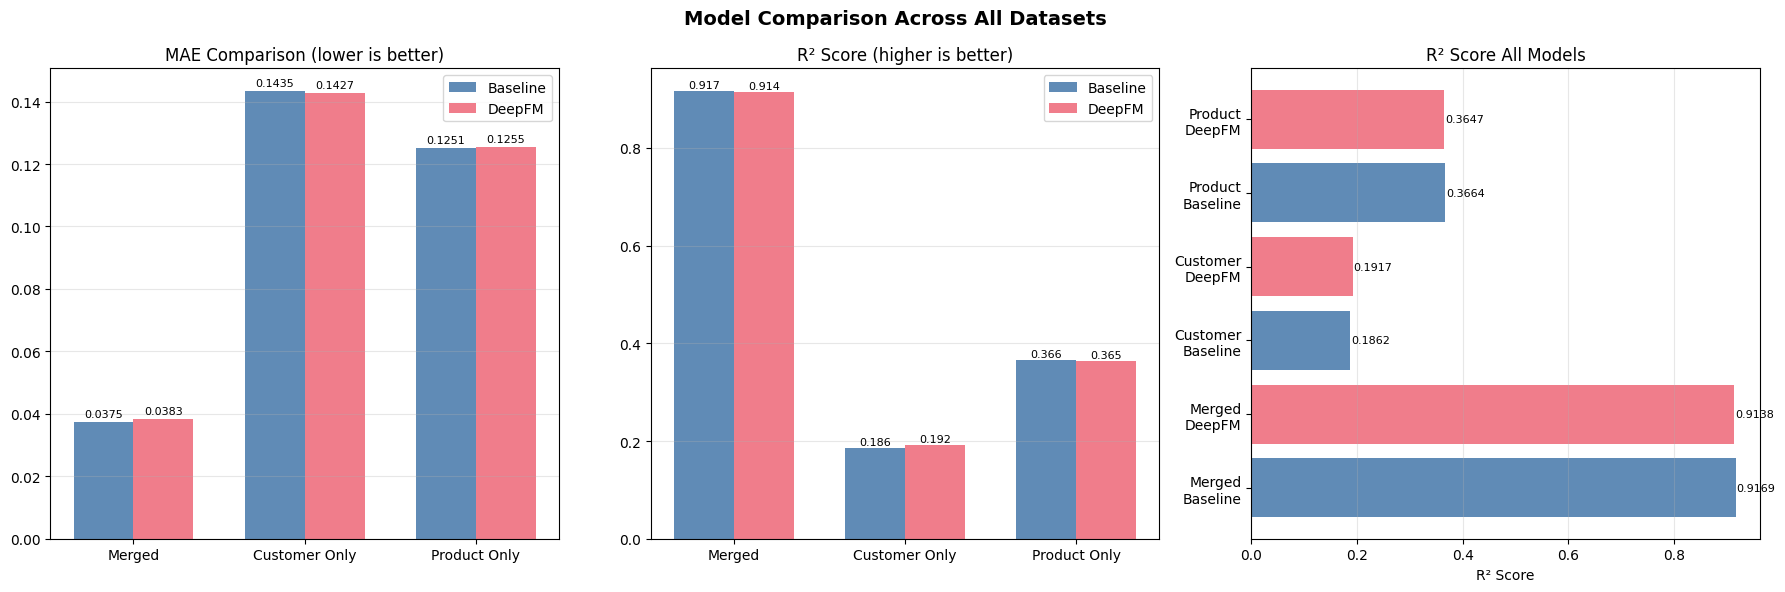


Comparison graph saved to Drive!


In [27]:
# Final 3-Dataset Comparison

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Get all predictions
b_merged_preds  = baseline_good.predict(X_te, verbose=0).flatten()
d_merged_preds  = deepfm_good.predict(X_te, verbose=0).flatten()
b_cust_preds    = baseline_cust.predict(X_te_c, verbose=0).flatten()
d_cust_preds    = deepfm_cust.predict(X_te_c, verbose=0).flatten()
b_prod_preds    = baseline_prod.predict(X_te_p, verbose=0).flatten()
d_prod_preds    = deepfm_prod.predict(X_te_p, verbose=0).flatten()

# Calculate metrics
def get_metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':   r2_score(y_true, y_pred)
    }

results = {
    'Merged - Baseline':   get_metrics(y_te,   b_merged_preds),
    'Merged - DeepFM':     get_metrics(y_te,   d_merged_preds),
    'Customer - Baseline': get_metrics(y_te_c, b_cust_preds),
    'Customer - DeepFM':   get_metrics(y_te_c, d_cust_preds),
    'Product - Baseline':  get_metrics(y_te_p, b_prod_preds),
    'Product - DeepFM':    get_metrics(y_te_p, d_prod_preds),
}

print("=" * 65)
print(f"{'Dataset & Model':<25} {'MAE':>10} {'RMSE':>10} {'R2 Score':>10}")
print("=" * 65)
for name, m in results.items():
    print(f"{name:<25} {m['MAE']:>10.4f} {m['RMSE']:>10.4f} {m['R2']:>10.4f}")
print("=" * 65)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Comparison Across All Datasets', fontsize=14, fontweight='bold')

datasets = ['Merged', 'Customer Only', 'Product Only']
baseline_mae = [results['Merged - Baseline']['MAE'],
                results['Customer - Baseline']['MAE'],
                results['Product - Baseline']['MAE']]
deepfm_mae   = [results['Merged - DeepFM']['MAE'],
                results['Customer - DeepFM']['MAE'],
                results['Product - DeepFM']['MAE']]
baseline_r2  = [results['Merged - Baseline']['R2'],
                results['Customer - Baseline']['R2'],
                results['Product - Baseline']['R2']]
deepfm_r2    = [results['Merged - DeepFM']['R2'],
                results['Customer - DeepFM']['R2'],
                results['Product - DeepFM']['R2']]

x = np.arange(len(datasets))
width = 0.35

# MAE
axes[0].bar(x - width/2, baseline_mae, width, label='Baseline', color='#4477AA', alpha=0.85)
axes[0].bar(x + width/2, deepfm_mae,   width, label='DeepFM',   color='#EE6677', alpha=0.85)
axes[0].set_title('MAE Comparison (lower is better)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(datasets)
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)
for i, (b, d) in enumerate(zip(baseline_mae, deepfm_mae)):
    axes[0].text(i - width/2, b + 0.001, f'{b:.4f}', ha='center', va='bottom', fontsize=8)
    axes[0].text(i + width/2, d + 0.001, f'{d:.4f}', ha='center', va='bottom', fontsize=8)

# R2
axes[1].bar(x - width/2, baseline_r2, width, label='Baseline', color='#4477AA', alpha=0.85)
axes[1].bar(x + width/2, deepfm_r2,   width, label='DeepFM',   color='#EE6677', alpha=0.85)
axes[1].set_title('R² Score (higher is better)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(datasets)
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)
for i, (b, d) in enumerate(zip(baseline_r2, deepfm_r2)):
    axes[1].text(i - width/2, b + 0.002, f'{b:.3f}', ha='center', va='bottom', fontsize=8)
    axes[1].text(i + width/2, d + 0.002, f'{d:.3f}', ha='center', va='bottom', fontsize=8)

# Summary table as bar
model_names = ['Merged\nBaseline', 'Merged\nDeepFM',
               'Customer\nBaseline', 'Customer\nDeepFM',
               'Product\nBaseline', 'Product\nDeepFM']
all_r2 = [results[k]['R2'] for k in results.keys()]
colors = ['#4477AA', '#EE6677'] * 3
axes[2].barh(model_names, all_r2, color=colors, alpha=0.85)
axes[2].set_title('R² Score All Models')
axes[2].set_xlabel('R² Score')
axes[2].grid(True, axis='x', alpha=0.3)
for i, v in enumerate(all_r2):
    axes[2].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ecom_recommendation_project/all_datasets_comparison.png', dpi=150)
plt.show()

print("\nComparison graph saved to Drive!")

In [28]:
# Save all models
import pickle

deepfm_good.save('/content/drive/MyDrive/ecom_recommendation_project/deepfm_merged.keras')
deepfm_cust.save('/content/drive/MyDrive/ecom_recommendation_project/deepfm_customer.keras')
deepfm_prod.save('/content/drive/MyDrive/ecom_recommendation_project/deepfm_product.keras')

with open('/content/drive/MyDrive/ecom_recommendation_project/scaler_final.pkl', 'wb') as f:
    pickle.dump(scaler_final, f)
with open('/content/drive/MyDrive/ecom_recommendation_project/scaler_cust.pkl', 'wb') as f:
    pickle.dump(scaler_cust, f)
with open('/content/drive/MyDrive/ecom_recommendation_project/scaler_prod.pkl', 'wb') as f:
    pickle.dump(scaler_prod, f)
with open('/content/drive/MyDrive/ecom_recommendation_project/cat_le.pkl', 'wb') as f:
    pickle.dump(cat_le, f)

print("All models and scalers saved!")

All models and scalers saved!
